# This in an attempt at GAN, Generative adversarial network using TENSORFLOW    

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms   #

from PIL import Image
import matplotlib.pyplot as plt

import os, random
import pandas as pd
import re
from tqdm import tqdm



In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [25]:
# =========================
# USER CONFIG
# =========================

FILTER_MODE = "keyword"   # "all", "keyword", "country"

KEYWORDS = {
    "hotdog": r"\bhot\s*dog\b",
    "burger": r"burger",
    "sandwich": r"sandwich"
}

SELECTED_KEY = "burger"   # which keyword to use

SELECTED_COUNTRY = "GER" 

USE_AUGMENTATION = True   # Yesyesyes toggle do you want to make 1 picture into 8 via flippin and mirrorin'
MAX_IMAGES = 6000

df = pd.read_csv("../data/grand_scraper_folder/unique_scrandle_cases_FULL.csv")


In [26]:
df = pd.read_csv("../data/grand_scraper_folder/unique_scrandle_cases_FULL.csv")

# convert country to list
df["country_list"] = df["country"].fillna("").apply(lambda x: x.split(" | "))

In [27]:
if FILTER_MODE == "keyword":
    pattern = KEYWORDS[SELECTED_KEY]

    mask = (
        df["title"].str.contains(pattern, case=False, na=False, regex=True) |
        df["subtitle"].str.contains(pattern, case=False, na=False, regex=True)
    )
    df = df[mask]

elif FILTER_MODE == "country":
    df = df[df["country_list"].apply(lambda x: SELECTED_COUNTRY in x)]

# "all" → do nothing

print("Filtered unique cases:", len(df))

Filtered unique cases: 556


In [28]:
base_folder = "../data/scrandle_padded_low_res_data"

def get_image_path(occurrence):
    date, rest = occurrence.split(":")
    match_id, side = rest.split("_")
    return os.path.join(base_folder, date, f"{match_id}_{side}.webp")

def safe_get_image_path(occurrence):
    path = get_image_path(occurrence)
    return path if os.path.exists(path) else None

image_paths = []

for _, row in df.iterrows():
    first_occ = row["occurrences"].split(" | ")[0]
    path = safe_get_image_path(first_occ)

    if path:
        image_paths.append(path)



        
# shuffle + limit
import random
random.shuffle(image_paths)

if MAX_IMAGES:
    image_paths = image_paths[:MAX_IMAGES]

print("Images used:", len(image_paths))


Images used: 556


In [29]:
IMG_SIZE = 128
NOISE_DIM = 128

class ScrandleDataset(Dataset):
    def __init__(self, paths, augment=False):
        self.paths = paths
        self.augment = augment

        self.transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def crop(self, img):
        w, h = img.size
        top = int(0.2 * h)
        right = int(0.8 * w)
        return img.crop((0, top, right, h))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.crop(img)
        img = self.transform(img)

        if not self.augment:
            return img

        # Yesyes augmentation → returns LIST (important!)
        imgs = []
        for k in range(4):
            r = torch.rot90(img, k, [1, 2])
            imgs.append(r)
            imgs.append(torch.flip(r, [2]))

        return imgs

In [30]:
dataset = ScrandleDataset(image_paths, augment=USE_AUGMENTATION)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [31]:
def unpack_batch(batch):
    if USE_AUGMENTATION:
        flat = []
        for item in batch:
            flat.extend(item)
        return torch.stack(flat)
    return batch

In [32]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),

            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        return torch.relu(x + self.block(x))  #  skip connection

In [33]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(NOISE_DIM, 8*8*256),
            nn.BatchNorm1d(8*8*256),
            nn.ReLU()
        )

        self.conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 8 → 16
            nn.BatchNorm2d(128),
            nn.ReLU(),

            ResBlock(128),   # ✅ NEW

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 16 → 32
            nn.BatchNorm2d(64),
            nn.ReLU(),

            ResBlock(64),    # ✅ NEW

            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 32 → 64
            nn.BatchNorm2d(32),
            nn.ReLU(),

            ResBlock(32),    # ✅ NEW

            nn.ConvTranspose2d(32, 3, 4, 2, 1),     # 64 → 128
            nn.Tanh()
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 256, 8, 8)
        return self.conv(x)

In [34]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),   # 128 → 64
            nn.LeakyReLU(0.2),

            ResBlock(64),   # ✅ NEW

            nn.Conv2d(64, 128, 4, 2, 1), # 64 → 32
            nn.LeakyReLU(0.2),

            ResBlock(128),  # ✅ NEW

            nn.Conv2d(128, 256, 4, 2, 1), # 32 → 16
            nn.LeakyReLU(0.2),

            ResBlock(256),  # ✅ NEW

            nn.Conv2d(256, 512, 4, 2, 1), # 16 → 8
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(512*8*8, 1))

    def forward(self, x):
        return self.net(x)

In [35]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCEWithLogitsLoss()

g_opt = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.5, 0.999))
d_opt = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))


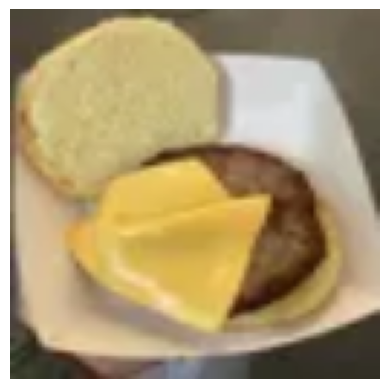

See, this is supposed to be a hotdog! (if you chose hotdog. If you chose burger, this is not a burger.)


In [36]:
sample = dataset[0]  # get first item

# handle augmentation
if USE_AUGMENTATION:
    sample = sample[0]   # take first of the 8 versions

img = (sample + 1) / 2   # back to [0,1]
img = img.permute(1, 2, 0)  # CHW → HWC

plt.imshow(img)
plt.axis("off")
plt.show()

print("See, this is supposed to be a hotdog! (if you chose hotdog. If you chose burger, this is not a burger.)")

In [37]:
def train_step(real):
    real = real.to(device)

    batch_size = real.size(0)
    noise = torch.randn(batch_size, NOISE_DIM, device=device)

    fake = G(noise)

    # ----- D -----
    real_out = D(real)
    fake_out = D(fake.detach())

    d_loss = (
        criterion(real_out, torch.ones_like(real_out)*0.85) +
        criterion(fake_out, torch.zeros_like(fake_out))
    ) ##You may change here

    d_opt.zero_grad()
    d_loss.backward()
    d_opt.step()

    # ----- G -----
    fake_out = D(fake)

    g_loss = criterion(fake_out, torch.ones_like(fake_out))

    g_opt.zero_grad()
    g_loss.backward()
    g_opt.step()

    return g_loss.item(), d_loss.item()


In [ ]:
EPOCHS = 5
# G is noise of fake image should be 0
#D score should give 0 for fake and 1 for real
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch}")

    for batch in tqdm(dataloader, desc=f"Epoch {epoch}"):
        batch = unpack_batch(batch)
        g_loss, d_loss = train_step(batch)


    print(f"G: {g_loss:.3f} | D: {d_loss:.3f}")

    
    G.eval()

    with torch.no_grad():
        noise = torch.randn(1, NOISE_DIM, device=device)
        fake = G(noise).cpu()

    G.train()


    img = (fake[0] + 1) / 2
    img = img.permute(1, 2, 0)

    plt.imshow(img)
    plt.axis("off")
    plt.show()


Epoch 0


Epoch 0:  22%|██▏       | 4/18 [02:12<07:26, 31.91s/it]

In [ ]:
torch.save(G.state_dict(), "generator.pth")
torch.save(D.state_dict(), "discriminator.pth")

print("Yesyesyes Models saved")

Yesyesyes Models saved


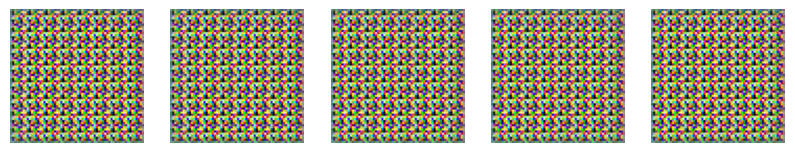

In [ ]:
num_samples = 5

noise = torch.randn(num_samples, 100, device=device)
fake = G(noise).detach().cpu()

plt.figure(figsize=(10, 4))

for i in range(num_samples):
    img = (fake[i] + 1) / 2
    img = img.permute(1, 2, 0)

    plt.subplot(1, num_samples, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()


In [ ]:
G = Generator().to(device) #This is to remember the model
G.load_state_dict(torch.load("generator.pth", map_location=device))
G.eval()

Generator(
  (fc): Sequential(
    (0): Linear(in_features=100, out_features=16384, bias=True)
    (1): BatchNorm1d(16384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (conv): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Tanh()
  )
)

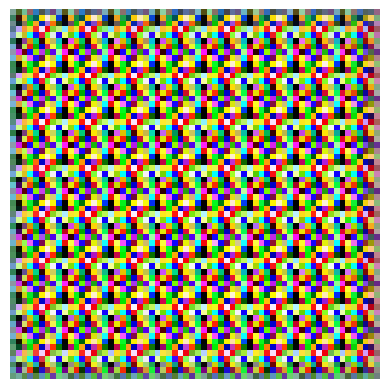

In [ ]:
noise = torch.randn(1, 100, device=device) #Generate new images.
fake = G(noise).detach().cpu()

img = (fake[0] + 1) / 2
img = img.permute(1, 2, 0)

plt.imshow(img)
plt.axis("off")
plt.show()
